# Discrete-Time Fourier Transform (DTFT)
Just transferring time domain to frequency domain.

## Definition
We define the discrete-time Fourier Transform of a sequence $x[n]$ as:

$$ X(e^{j\omega}) := \sum_{k=-\infty}^{\infty} x[k] e^{-j\omega k} $$

## Can We Recover $x[n]$ from $X(e^{j\omega})$?
The method to "go back" is to use the **Principle of Orthogonality**.

### Integral Representation:
$$ \int_{-\pi}^{\pi} X(e^{j\omega}) e^{j\omega n} d\omega = \int_{-\pi}^{\pi} \sum_{m=-\infty}^{\infty} x[m] e^{j\omega(n-m)} d\omega $$

### Interchanging Summation and Integration:
$$ \int_{-\pi}^{\pi} X(e^{j\omega}) e^{j\omega n} d\omega = \sum_{m=-\infty}^{\infty} x[m] \int_{-\pi}^{\pi} e^{j\omega(n-m)} d\omega $$

### Applying the Principle of Orthogonality:
$$
\int_{-\pi}^{\pi} e^{j\omega(n-m)} d\omega =
\begin{cases}
  2\pi, & \text{if } n = m \\
  0, & \text{if } n \neq m
\end{cases}
$$

### We get:
$$ x[n] = \frac{1}{2\pi} \int_{-\pi}^{\pi} X(e^{j\omega}) e^{j\omega n} d\omega $$

## The Forward and Inverse DTFT Pair:
### Forward DTFT:
$$ X(e^{j\omega}) = \sum_{k=-\infty}^{\infty} x[k] e^{-j\omega k} $$

### Inverse DTFT:
$$ x[n] = \frac{1}{2\pi} \int_{-\pi}^{\pi} X(e^{j\omega}) e^{j\omega n} d\omega $$

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, convolve, lfilter
import mplcursors

### DTFT Function in python :

In [2]:
# --- DTFT Function ---
def dtft(x, n, w):
    """
    Computes the Discrete-Time Fourier Transform (DTFT).

    Evaluates the DTFT formula at a specified set of frequency points:
        X(e^jw) = sum[ x[n] * e^(-jwn) ]  for all n

    Uses NumPy broadcasting to compute the full sum efficiently in one
    operation — building an (N, M) matrix of all (n, w) combinations,
    scaling by sample values, then summing over the time axis.

    Parameters
    ----------
    x : array-like
        Signal sample values (real or complex).
    n : array-like
        Time indices corresponding to each sample in x.
    w : array-like
        Frequency points (omega) at which to evaluate the transform.

    Returns
    -------
    X : np.ndarray (complex128), shape (len(w),)
        Complex frequency spectrum. Take np.abs(X) for magnitude,
        np.angle(X) for phase.
    """
    x = np.array(x, dtype=np.complex128)
    n = np.array(n)
    w = np.array(w)
    X = np.sum(x[:, None] * np.exp(-1j * n[:, None] * w), axis=0)
    return X

## Constant Function
Let's start by creating a function that is all ones. Of course, we cannot have an infinite number of ones on our computer. So we can start with 1024 ones. Then we compute the DTFT function.

Plotting a magnitude spectrum in dB simply means we take 20 times log10 of the value. Recall that the DTFT is complex, so the np.abs() function computes the magnitude of the complex number and the function np.angle() computes the phase of the complex number.

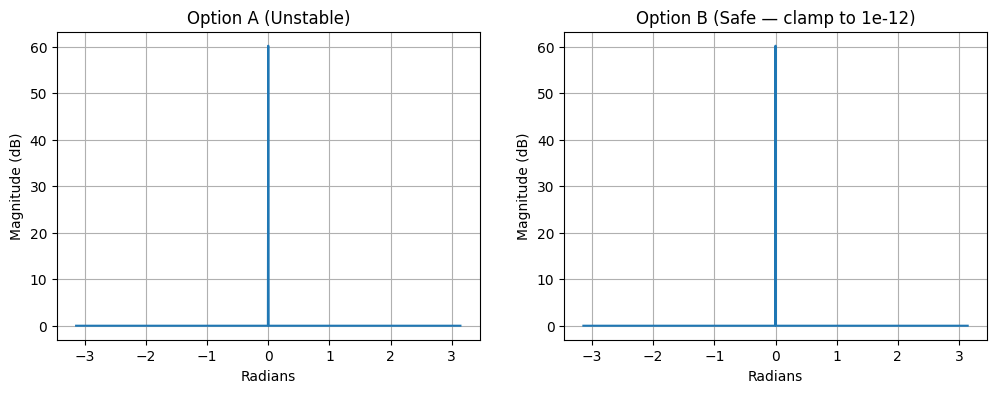

In [10]:
# --- Constant Function Example ---

# SAMPLE NUMBER (n) : ranges from 0 to 1024 (inclusive), creating a total of 1025 samples
n = np.arange(1025)

# SIGNAL (xn) : a constant function where every sample value is 1, matching the length of n
xn = np.ones_like(n)

# FREQUENCY POINTS (w) : 1025 points linearly spaced from -pi to pi, the integrating range for the DTFT
w = np.linspace(-np.pi, np.pi, 1025)

Xdtft = dtft(xn, n, w)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Option A - INCOMPLETE, UNSTABLE FOR VERY SMALL VALUES
ax1.plot(w, 20 * np.log10(np.abs(Xdtft)))
ax1.set_title("Option A (Unstable)")
ax1.set_xlabel("Radians")
ax1.set_ylabel("Magnitude (dB)")
ax1.grid(True)

# Option B - FULL MAGNITUDE IN DB FUNCTION (GO WITH THIS OPTION)
mag_db = 20 * np.log10(np.maximum(np.abs(Xdtft), 1e-12))
ax2.plot(w, mag_db)
ax2.set_title("Option B (Safe — clamp to 1e-12)")
ax2.set_xlabel("Radians")
ax2.set_ylabel("Magnitude (dB)")
ax2.grid(True)

Create the signal $ x[n] = \cos(\omega_0\, n)$ with $\omega_0 = \pi/4$ for n = 0 to 1024.

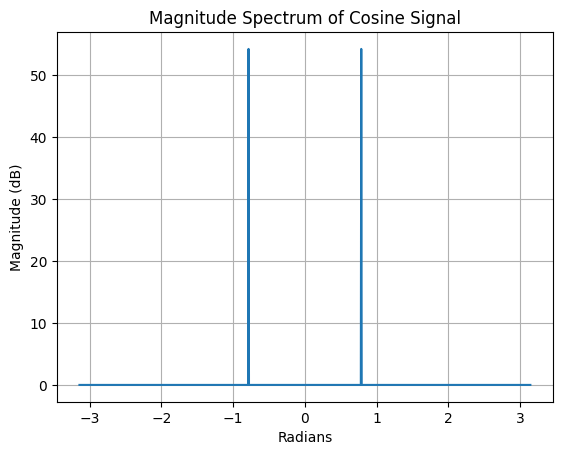

In [11]:
n = np.arange(1025) # Sample number from 0 to 1024 (inclusive)
xn = np.cos(np.pi/4 * n) # Cosine signal with frequency pi/4
w = np.linspace(-np.pi, np.pi, 1025) # Integrating range for DTFT
Xdtft = dtft(xn, n, w)

mag_db = 20 * np.log10(np.maximum(np.abs(Xdtft), 1e-12))

plt.figure()
plt.plot(w, mag_db)
plt.title("Magnitude Spectrum of Cosine Signal")
plt.xlabel("Radians")
plt.ylabel("Magnitude (dB)")
plt.grid()

Create the signal $x[n] = \sin(\omega_0\, n)$ with $\omega_0 = \pi/4$ for n = 0 to 1024.

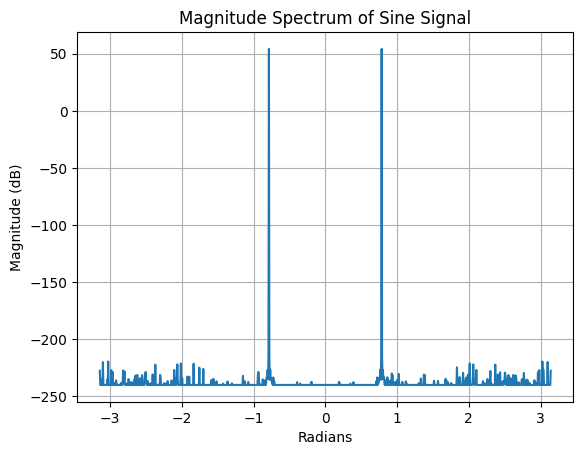

In [12]:
n = np.arange(1025) # Sample number from 0 to 1024 (inclusive)
xn = np.sin(np.pi/4 * n) # Sine signal with frequency pi/4
w = np.linspace(-np.pi, np.pi, 1025) # Integrating range for DTFT
Xdtft = dtft(xn, n, w)

mag_db = 20 * np.log10(np.maximum(np.abs(Xdtft), 1e-12))

plt.figure()
plt.plot(w, mag_db)
plt.title("Magnitude Spectrum of Sine Signal")
plt.xlabel("Radians")
plt.ylabel("Magnitude (dB)")
plt.grid()

## Exploring the Dirichlet Kernel Lobes
Create the signal $x[n] = \sin(\omega_0\, n)$ with $\omega_0 = \pi/4$ for n = 0 to 1024.

This time increase the frequency resolution by letting $\omega$ have 20001 points. Because the sinuoid does not continue infinitely in time, the peak in the frequency spectrum is not pure. The sinuoidal signal is as if it has been windowed. This produces the Dirichlet kernel lobes. You should see this clearly if you
limit the x-axis to $\pi - 0.2$ to $\pi + 0.2$ and limit the y-axis to $-80$ to $5$.

NOTE: We are using a different mag_dB function here, one that is normalized.

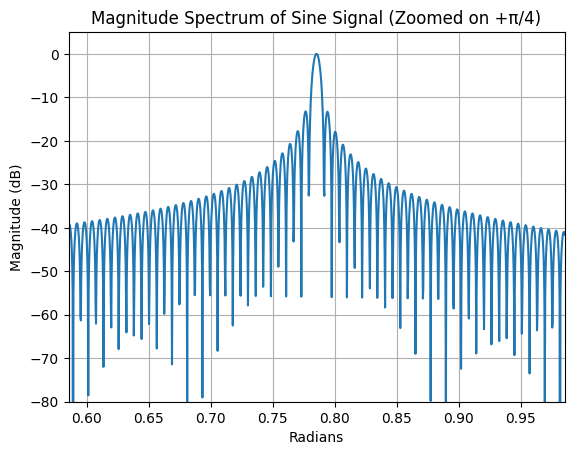

In [ ]:
n = np.arange(1025)
xn = np.sin(np.pi/4 * n)
w = np.linspace(-np.pi, np.pi, 20001) # Omega now has 20,001 points for a smoother plot
Xdtft = dtft(xn, n, w)

# FULL MAGNITUDE IN DB (NORMALIZED) :
mag = np.abs(Xdtft)
mag = mag / np.max(mag) # Normalize to max value (0 dB)
mag_db = 20 * np.log10(np.maximum(mag, 1e-12))

plt.figure()
plt.plot(w, mag_db)

#Plot limits, zoomed on +π/4
plt.xlim([np.pi/4 - 0.2, np.pi/4 + 0.2])
plt.ylim([-80, 5])

plt.title("Magnitude Spectrum of Sine Signal (Zoomed on +π/4)")
plt.xlabel("Radians")
plt.ylabel("Magnitude (dB)")
plt.grid()